In [2]:
window_size = 7
shift_size = window_size // 2
input_resolution = (56, 56)
import torch
from transformers.models.swin.modeling_swin import window_partition
if shift_size > 0:
    # calculate attention mask for SW-MSA
    H, W = input_resolution
    img_mask = torch.zeros((1, H, W, 1))  # 1 H W 1
    h_slices = (slice(0, -window_size),
                slice(-window_size, -shift_size),
                slice(-shift_size, None))
    w_slices = (slice(0, -window_size),
                slice(-window_size, -shift_size),
                slice(-shift_size, None))
    cnt = 0
    for h in h_slices:
        for w in w_slices:
            img_mask[:, h, w, :] = cnt
            cnt += 1
    # [64, 49, 49]
    mask_windows = window_partition(img_mask, window_size)  # nW, window_size, window_size, 1
    mask_windows = mask_windows.view(-1, window_size * window_size)
    attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
    attn_mask = attn_mask.masked_fill(attn_mask != 0, float(-100.0)).masked_fill(attn_mask == 0, float(0.0))

/var/folders/z6/dz0yb7c95n9dtykytfy42j0r0000gn/T/ipykernel_18174/1292129245.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


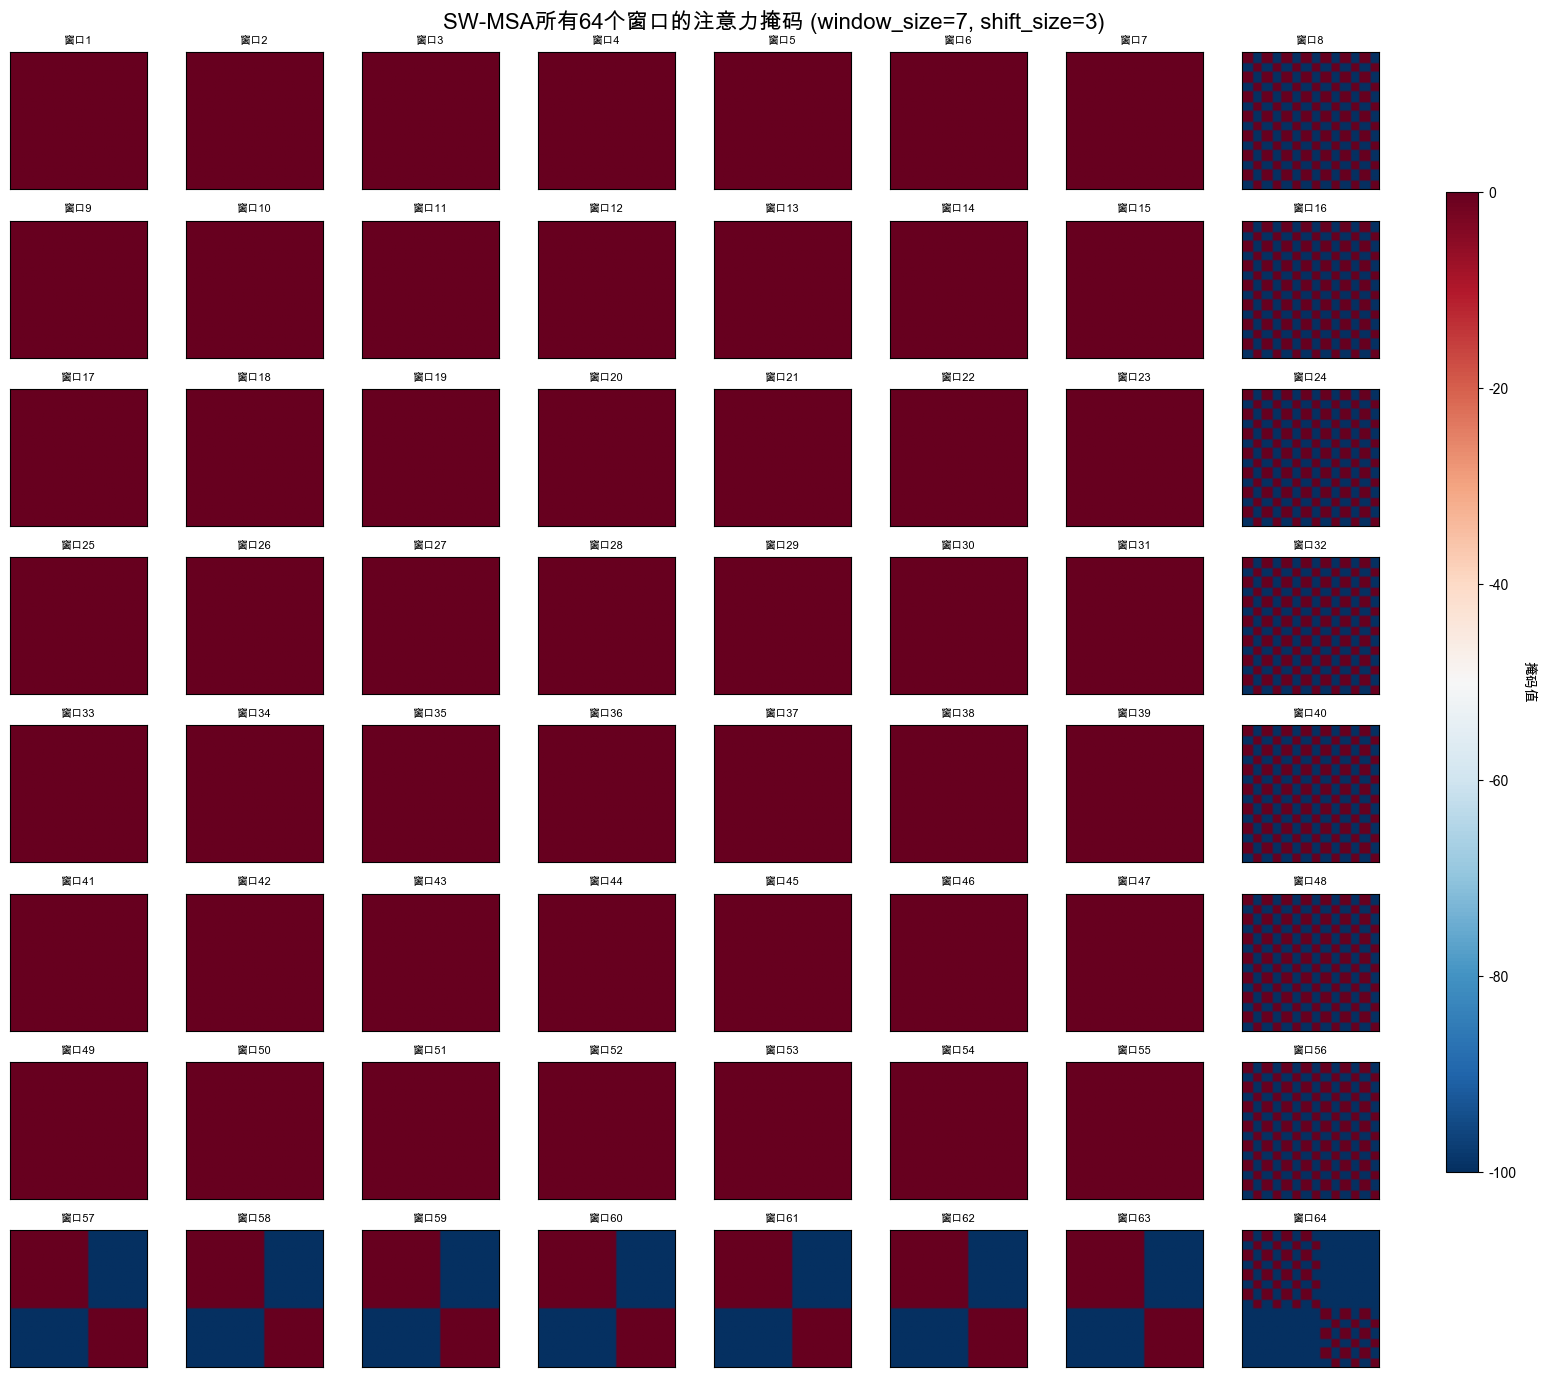

attn_mask形状: torch.Size([64, 49, 49])
窗口数量: 64
单个窗口掩码形状: torch.Size([49, 49])

不同掩码模式的窗口分组（共4种模式）：
模式1: 窗口编号 [0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 32, 33, 34, 35, 36, 37, 38, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54] (共49个窗口)
模式2: 窗口编号 [7, 15, 23, 31, 39, 47, 55] (共7个窗口)
模式3: 窗口编号 [56, 57, 58, 59, 60, 61, 62] (共7个窗口)
模式4: 窗口编号 [63] (共1个窗口)


In [3]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(8, 8, figsize=(16, 14))
fig.suptitle(f'SW-MSA所有64个窗口的注意力掩码 (window_size={window_size}, shift_size={shift_size})', fontsize=16)

for idx, ax in enumerate(axes.flatten()):
    window_mask = attn_mask[idx].numpy()
    im = ax.imshow(window_mask, cmap='RdBu_r', vmin=-100, vmax=0)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'窗口{idx+1}', fontsize=8)

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.set_ylabel('掩码值', rotation=-90, va="bottom", fontsize=10)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

print(f'attn_mask形状: {attn_mask.shape}')  # (64, 49, 49)
print(f'窗口数量: {attn_mask.shape[0]}')
print(f'单个窗口掩码形状: {attn_mask[0].shape}')

# NT: 统计不同掩码模式的窗口分组
unique_masks = {}
for idx in range(attn_mask.shape[0]):
    mask_hash = hash(attn_mask[idx].cpu().numpy().tobytes())
    if mask_hash not in unique_masks:
        unique_masks[mask_hash] = []
    unique_masks[mask_hash].append(idx)

print(f'\n不同掩码模式的窗口分组（共{len(unique_masks)}种模式）：')
for i, (hash_val, window_ids) in enumerate(unique_masks.items()):
    print(f'模式{i+1}: 窗口编号 {window_ids} (共{len(window_ids)}个窗口)')